# Fitzpatrick Dataset Analysis

## Imports

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Reading the Data

In [11]:
CSV_PATH = "SimThresh_T_A2_T_0.99_0.70_FC_T_KeepOne_Out_T_OutThresh_None_0FST_F.csv"
df = pd.read_csv(CSV_PATH)
df.head()

,filepath,filename,diag,fst,partition,md5hash,fitzpatrick,label,nine_partition_label,three_partition_label,qc,url,url_alphanum,orig_img_name,new_img_name
0,ne-de_361/ne-de_f2_61_3a96728f.jpg,ne-de_f2_61_3a96728f,ne-de,2,train,3a96728fb161fc25b3597d3996dc4e4a,2,neutrophilic dermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppyode...,3a96728fb161fc25b3597d3996dc4e4a.jpg,ne-de_f2_61_3a96728f.jpg
1,lu-er_410/lu-er_f1_89_07be6be3.jpg,lu-er_f1_89_07be6be3,lu-er,1,train,07be6be3cbebd04ff9bfcab50b75378b,1,lupus erythematosus,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicssubac...,07be6be3cbebd04ff9bfcab50b75378b.jpg,lu-er_f1_89_07be6be3.jpg
2,me_261/me_f0_194_72bcd875.jpg,me_f0_194_72bcd875,me,0,train,72bcd875e7a573b4139883059e69328d,-1,melanoma,malignant melanoma,malignant,NaN,http://atlasdermatologico.com.br/img?imageId=4264,httpwwwatlasdermatologicocombrimgimageId4264.jpg,72bcd875e7a573b4139883059e69328d.jpg,me_f0_194_72bcd875.jpg
3,dr-er_200/dr-er_f4_36_dfa97968.jpg,dr-er_f4_36_dfa97968,dr-er,4,train,dfa9796851f899e99961603c951742fa,4,drug eruption,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicddruge...,dfa9796851f899e99961603c951742fa.jpg,dr-er_f4_36_dfa97968.jpg
4,ju-xa_149/ju-xa_f2_118_be506d4a.jpg,ju-xa_f2_118_be506d4a,ju-xa,2,train,be506d4a799385099ac85daa695d6df3,2,juvenile xanthogranuloma,inflammatory,non-neoplastic,NaN,http://atlasdermatologico.com.br/img?imageId=8098,httpwwwatlasdermatologicocombrimgimageId8098.jpg,be506d4a799385099ac85daa695d6df3.jpg,ju-xa_f2_118_be506d4a.jpg


## Shape and Columns

In [12]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (11394, 15)
Columns: ['filepath', 'filename', 'diag', 'fst', 'partition', 'md5hash', 'fitzpatrick', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum', 'orig_img_name', 'new_img_name']


## Missing Values

In [13]:
df.isna().sum()

filepath                     0
filename                     0
diag                         0
fst                          0
partition                    0
md5hash                      0
fitzpatrick                  0
label                        0
nine_partition_label         0
three_partition_label        0
qc                       11064
url                         35
url_alphanum                 0
orig_img_name                0
new_img_name                 0
dtype: int64

## Partition Distribution

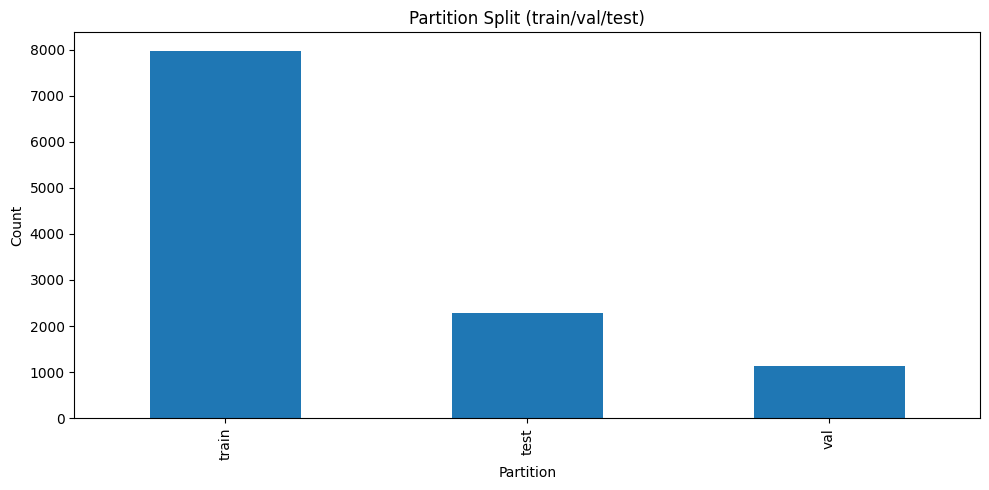

In [14]:
def plot_bar(series, title, xlabel, ylabel="Count", top_n=None):
    plt.figure(figsize=(10, 5))
    if top_n:
        series = series.head(top_n)
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

plot_bar(
    df["partition"].value_counts(),
    "Partition Split (train/val/test)",
    "Partition"
)

## 3-Class Distribution

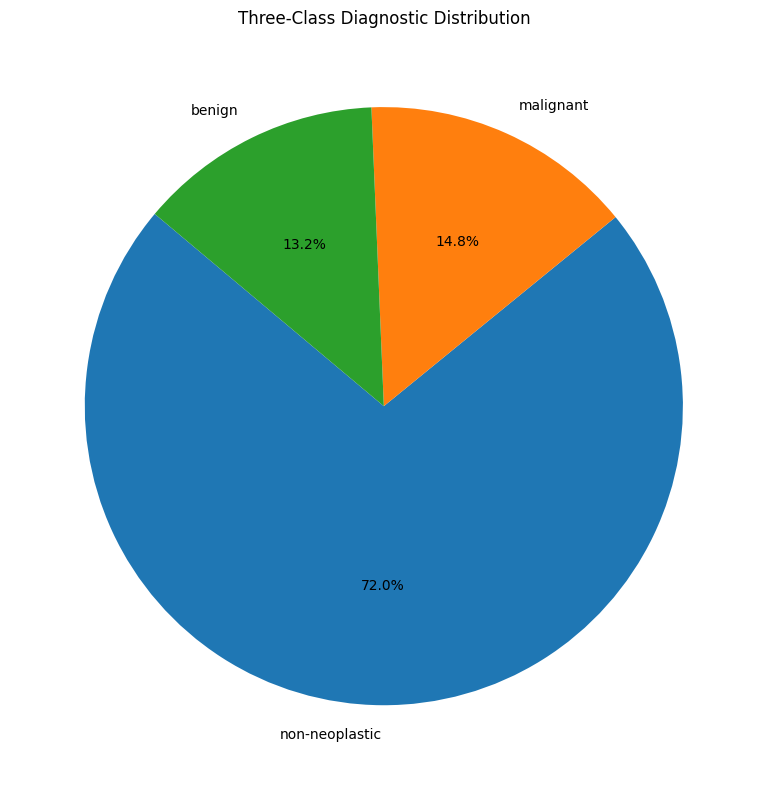

In [15]:
three_counts = df["three_partition_label"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    three_counts, 
    labels=three_counts.index, 
    autopct="%1.1f%%", 
    startangle=140
)
plt.title("Three-Class Diagnostic Distribution")
plt.tight_layout()
plt.show()

## 9-Class Distribution

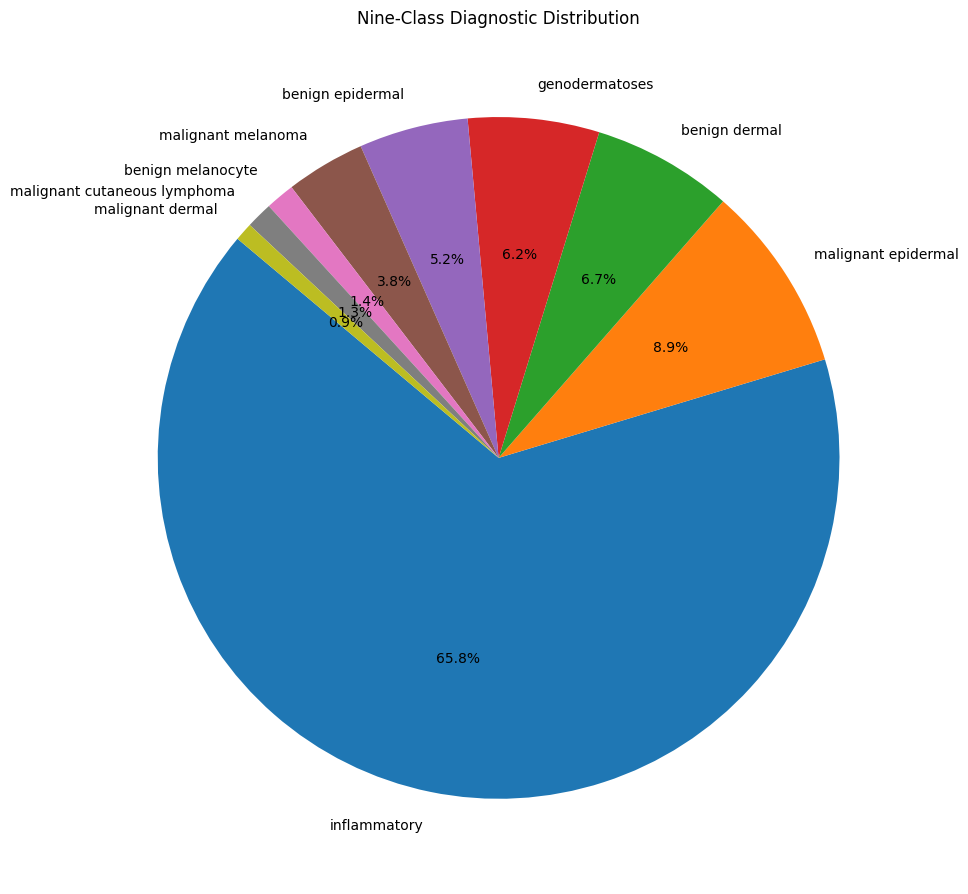

In [16]:
nine_counts = df["nine_partition_label"].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(
    nine_counts, 
    labels=nine_counts.index, 
    autopct="%1.1f%%", 
    startangle=140
)
plt.title("Nine-Class Diagnostic Distribution")
plt.tight_layout()
plt.show()

## Skin Tone Distribution

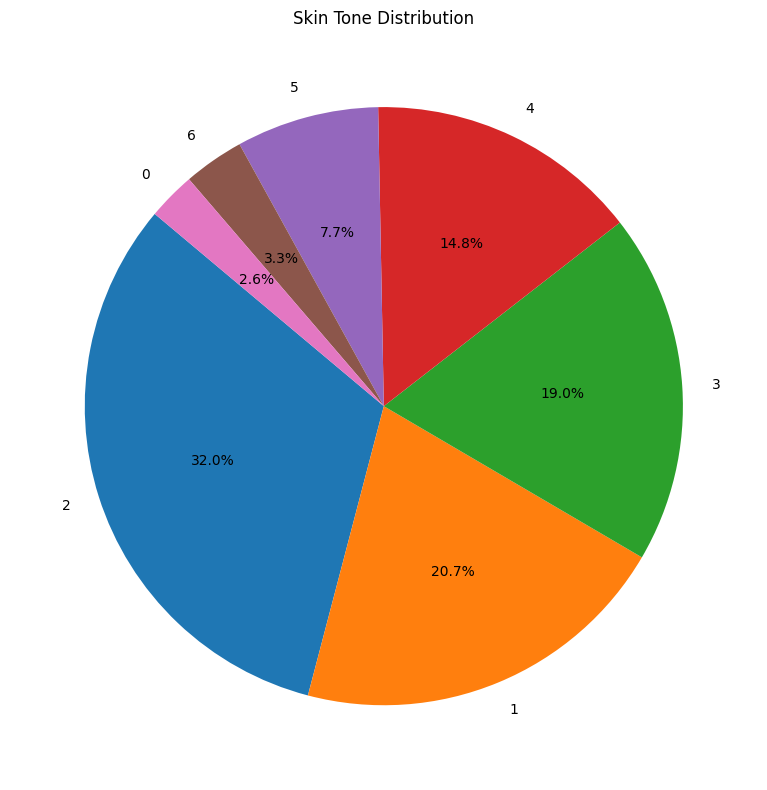

In [17]:
skin_tones = df["fst"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    skin_tones, 
    labels=skin_tones.index, 
    autopct="%1.1f%%", 
    startangle=140
)
plt.title("Skin Tone Distribution")
plt.tight_layout()
plt.show()

## Cross-Tabs for Fairness / Label Mix


=== Crosstab: FST × Three-Class ===
three_partition_label  benign  malignant  non-neoplastic
fst                                                     
0                          44         60             192
1                         337        359            1657
2                         487        575            2587
3                         305        336            1519
4                         209        223            1252
5                          99         88             692
6                          26         42             305


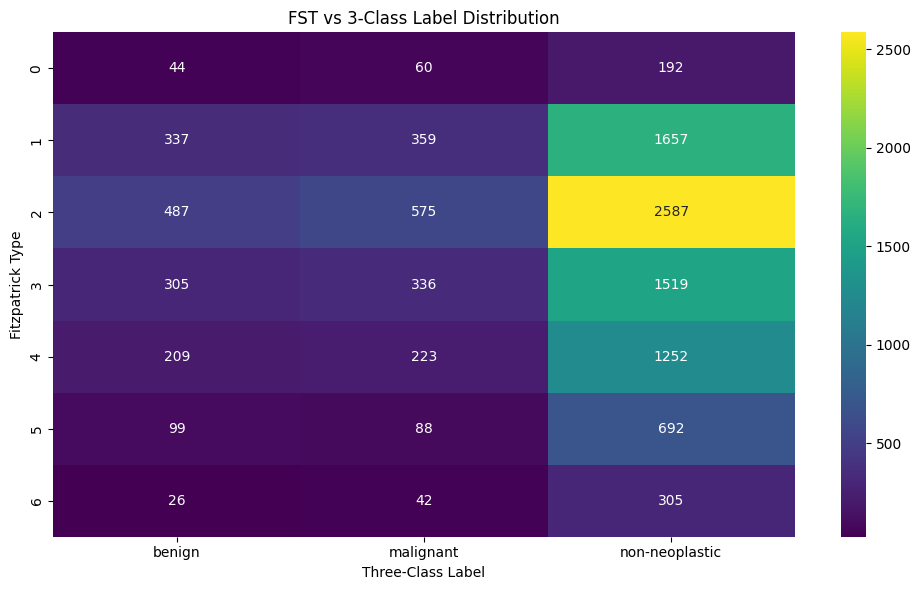

In [18]:
ct_fst_diag = pd.crosstab(df["fst"], df["three_partition_label"])
print("\n=== Crosstab: FST × Three-Class ===")
print(ct_fst_diag)

plt.figure(figsize=(10, 6))
sns.heatmap(ct_fst_diag, annot=True, fmt="d", cmap="viridis")
plt.title("FST vs 3-Class Label Distribution")
plt.ylabel("Fitzpatrick Type")
plt.xlabel("Three-Class Label")
plt.tight_layout()
plt.show()